In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
(X_train,y_train),(X_test,y_test) = datasets.mnist.load_data()
X_train.shape

(60000, 28, 28)

In [3]:
train_image=X_train.reshape((60000,28,28,1))
test_image = X_test.reshape((10000,28,28,1))

In [4]:
train_image,test_image = train_image/255.0,test_image/255.0

In [5]:
model = Sequential()
model.add(Input(shape=(28,28,1)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 32)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 32)          9248      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 1, 1, 32)         0

In [6]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [7]:
h=model.fit(train_image,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 8s 3ms/step - loss: 0.2509 - accuracy: 0.9216
Epoch 2/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0921 - accuracy: 0.9724
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0702 - accuracy: 0.9789
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0594 - accuracy: 0.9816
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0475 - accuracy: 0.9851


In [8]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 29.8400 - accuracy: 0.9514


[29.840049743652344, 0.9513999819755554]

In [10]:
import cv2 as cv
cv.__version__

'4.6.0'

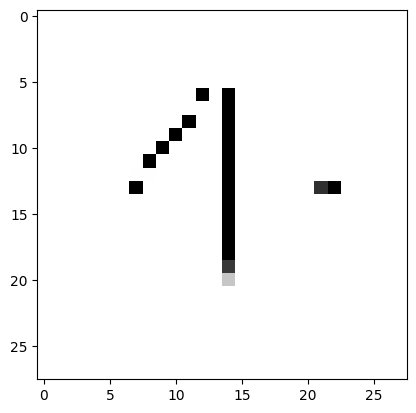

1/1 [==============================] - 0s 318ms/step
[[0.02141476 0.7712899  0.02812286 0.01257367 0.03495435 0.02716651
  0.01360125 0.05887561 0.02211533 0.00988571]]
예측된 숫자 = 1


In [12]:
image = cv.imread('test/num4.png',cv.IMREAD_GRAYSCALE)
image = cv.resize(image,(28,28))
image = image.astype('float32')
image = image.reshape(1,784)
image = 255-image
image = image/255

plt.imshow(image.reshape(28,28),cmap='Grays')
plt.show()

pred = model.predict(image.reshape(1,28,28))
print(pred)
print('예측된 숫자 =',pred.argmax())